# 18 — Final trio dashboard: return per unit of risk

One-page visual companion to the `15_2` final comparison. Three lines, one
common window (2019-01-03 → 2026-01-30, each re-based at the window start):

- **Static B&H 16-26** — the raw-return benchmark,
- **Factor ext26** — the date-as-of macro-factor line (no SJM),
- **SJM×crowding de-risk v2 ext26** — the drawdown-armed overlay (nb17).

The question the dashboard answers is not "who made the most money" (static
B&H does, with the deepest drawdown) but **how much return each line earns per
unit of risk taken** — total volatility, drawdown, and residual risk under a
single-factor raw-return SPY regression.

Everything recomputes offline from the persisted artifacts with the same
conventions as `15_2` (active-span trim, raw-return SPY regression, price-only
SPY benchmark caveat). The headline numbers are pinned by assertions — if an
artifact drifts, this notebook fails loudly instead of plotting stale claims.

> Caveats inherited from `15_2`: SPY is price-only (dividends missing), so the
> regression intercept and residual-risk numbers depend on that benchmark choice.
> They remain useful as internal, same-source comparisons, but they are not
> excess-return CAPM/Jensen-alpha claims. SSR point estimates are shown as
> descriptive stability signals; realized simulation curves only, no forecast-accuracy
> claims.

In [1]:
import sys, warnings
from pathlib import Path

warnings.filterwarnings("ignore")
REPO = Path.cwd().parent
sys.path.insert(0, str(REPO))
sys.path.insert(0, str(REPO / "workbook"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from macro_framework import skill_metric as sk
from macro_framework.ssr import compute_ssr

DATA = REPO / "data"
TRADING_DAYS = 252

TRIO = [
    ("static_bh_equity_2016_2026", "Static B&H 16-26", "#2f6db3"),
    ("factor_equity_ext2026", "Factor ext26", "#e8710a"),
    ("sjm_crowding_derisk_v2_equity_ext2026", "SJM×crowding de-risk v2 ext26", "#8656c9"),
]


def active_value(value):
    moving = value[value.ne(value.iloc[0])]
    if moving.empty:
        return value
    first_move = moving.index.min()
    prior = value.index[value.index < first_move]
    return value.loc[(prior.max() if len(prior) else first_move):]


def metric_block(v: pd.Series) -> dict:
    r = v.pct_change().dropna()
    yrs = max((v.index[-1] - v.index[0]).days / 365.25, 1 / 365.25)
    cagr = float((v.iloc[-1] / v.iloc[0]) ** (1 / yrs) - 1)
    vol = float(r.std(ddof=1) * np.sqrt(TRADING_DAYS))
    sharpe = float(r.mean() / r.std(ddof=1) * np.sqrt(TRADING_DAYS))
    dd = float((v / v.cummax() - 1).min())
    calmar = float(cagr / abs(dd)) if dd else np.nan
    return {"returns": r, "CAGR": cagr, "vol": vol, "Sharpe": sharpe, "maxDD": dd, "Calmar": calmar}


vals = {lbl: active_value(pd.read_parquet(DATA / f"{stem}.parquet")["value"])
        for stem, lbl, _ in TRIO}
t_start = max(v.index.min() for v in vals.values())
t_end = min(v.index.max() for v in vals.values())
spy_px = pd.read_parquet(DATA / "etf_prices_wide_2013_2026.parquet")["SPY"].dropna()
print(f"common window: {t_start:%Y-%m-%d} → {t_end:%Y-%m-%d}")
print(f"regression factor sample ends: {spy_px.index.max():%Y-%m-%d}")

M = {}
for stem, lbl, color in TRIO:
    v = vals[lbl].loc[t_start:t_end]
    mb = metric_block(v)
    r = mb["returns"]
    spx = sk.basket_residual(r, spy_px.pct_change().rename("SPY").to_frame("SPY"), periods_per_year=TRADING_DAYS)
    M[lbl] = {"color": color, "CAGR": mb["CAGR"], "vol": mb["vol"],
              "Sharpe": mb["Sharpe"], "maxDD": mb["maxDD"], "Calmar": mb["Calmar"],
              "alpha": float(spx.alpha_ann), "idio": float(spx.idio_vol_ann),
              "Appraisal": float(spx.appraisal) if spx.appraisal is not None else np.nan,
              "SSR": float(compute_ssr(r).ssr)}

# provenance check: reuse the already generated trio tear-sheet export rather than
# pinning older headline numbers that depended on a different annualization basis.
trio_csv = DATA / "tear_sheet" / "tear_sheet_trio_ext2026.csv"
if trio_csv.exists():
    trio = pd.read_csv(trio_csv).set_index("Label")
    trio_map = {"Static B&H 16-26": "Static B&H 16-26",
                "Factor ext26": "Factor ext26",
                "SJM×crowding de-risk v2 ext26": "SJM×crowding de-risk v2 ext26"}
    for lbl in [lbl for _, lbl, _ in TRIO]:
        row = trio.loc[trio_map[lbl]]
        for key, col, tol in [("CAGR", "CAGR", 1e-9), ("vol", "Ann. Volatility", 1e-9),
                              ("Sharpe", "Sharpe", 1e-9), ("maxDD", "Max Drawdown", 1e-9),
                              ("Calmar", "Calmar", 1e-9), ("alpha", "Regression intercept (ann.)", 1e-9),
                              ("idio", "Residual vol (ann., SPY reg)", 1e-9),
                              ("Appraisal", "Appraisal Ratio (intercept / residual vol)", 1e-9)]:
            assert abs(M[lbl][key] - float(row[col])) < tol, (lbl, key, M[lbl][key], row[col])
    print("self-check vs tear_sheet_trio_ext2026.csv: PASS")
else:
    print("tear_sheet_trio_ext2026.csv missing — self-check skipped")

tbl = pd.DataFrame(M).T.drop(columns="color")
tbl.columns = ["CAGR", "Ann. vol σ", "Sharpe (rf=0)", "Max DD", "Calmar",
               "Regression intercept (ann.)", "Residual vol σε", "Appraisal", "SSR"]
tbl.style.format({"CAGR": "{:.1%}", "Ann. vol σ": "{:.1%}", "Max DD": "{:.1%}",
                  "Regression intercept (ann.)": "{:.1%}", "Residual vol σε": "{:.1%}", "Sharpe (rf=0)": "{:.2f}",
                  "Calmar": "{:.2f}", "Appraisal": "{:.2f}", "SSR": "{:.2f}"})

common window: 2019-01-02 → 2026-01-30
regression factor sample ends: 2026-05-28
self-check vs tear_sheet_trio_ext2026.csv: PASS


,CAGR,Ann. vol σ,Sharpe (rf=0),Max DD,Calmar,Regression intercept (ann.),Residual vol σε,Appraisal,SSR
Static B&H 16-26,18.1%,14.6%,1.23,-19.6%,0.92,8.1%,7.6%,1.06,0.14
Factor ext26,13.7%,9.2%,1.48,-12.1%,1.14,10.0%,8.0%,1.24,0.13
SJM×crowding de-risk v2 ext26,13.1%,8.1%,1.59,-8.4%,1.56,10.2%,7.4%,1.38,0.14


## 1. Risk–return maps — where each line sits, and what a unit of risk buys

Both panels put **risk on x, return on y**, with gray reference rays from the
origin: every point on a ray earns the same return per unit of risk, and
steeper is better. Left: total risk (CAGR against annualized volatility, rays
= CAGR/σ — the geometric cousin of a raw-return Sharpe; the exact ratio is in
each label). Right: regression-adjusted (annualized raw-return SPY-regression
intercept against residual volatility σε, rays = the appraisal ratio exactly).

Static B&H sits far right: more return, bought with much more risk. The two
factor lines sit upper-left of it on both maps — and the v2 overlay is the
only line that *reduces* risk (σ and σε) while holding the regression intercept
roughly constant.

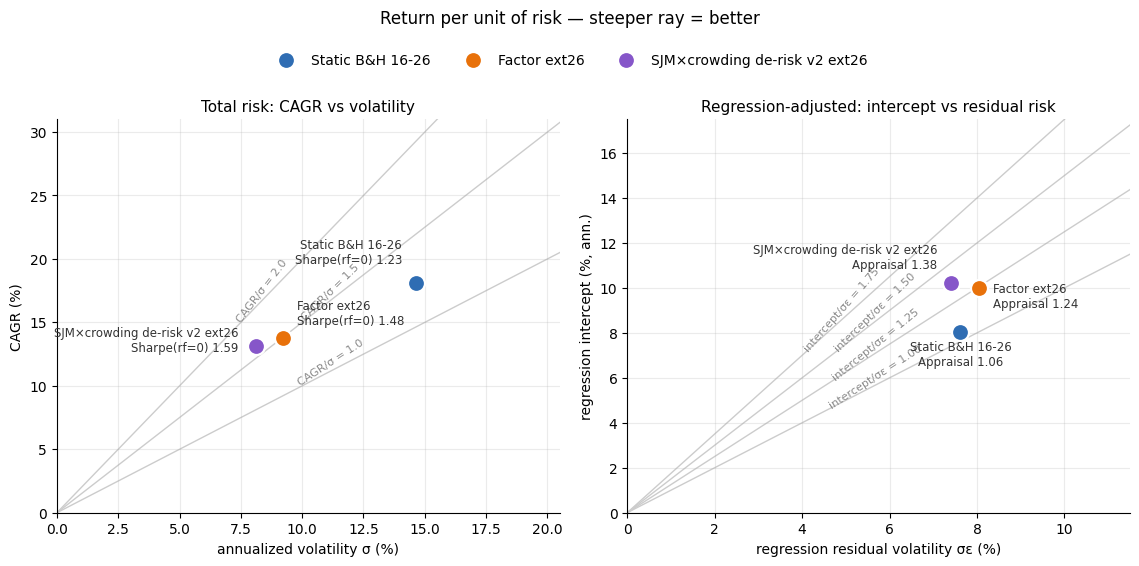

In [2]:
plt.rcParams.update({"font.size": 10, "axes.spines.top": False, "axes.spines.right": False})
INK, MUTED = "#333333", "#8a8a8a"

fig, (axA, axB) = plt.subplots(1, 2, figsize=(11.5, 5.2))

def ray_panel(ax, slopes, slope_fmt, xmax, ymax, frac):
    ax.set_xlim(0, xmax); ax.set_ylim(0, ymax)
    ax.grid(alpha=0.25, zorder=0)
    for s in slopes:
        ax.plot([0, xmax], [0, s * xmax], color="#cccccc", lw=1, zorder=1)
        xe = min(xmax, ymax / s)
        p0 = ax.transData.transform((0.0, 0.0))
        p1 = ax.transData.transform((xe, s * xe))
        ang = np.degrees(np.arctan2(p1[1] - p0[1], p1[0] - p0[0]))
        ax.annotate(slope_fmt.format(s), (frac * xe, frac * s * xe), color=MUTED,
                    fontsize=8, ha="center", va="bottom", rotation=ang,
                    rotation_mode="anchor", xytext=(0, 2), textcoords="offset points")

XA, YA = 20.5, 31.0
ray_panel(axA, (1.0, 1.5, 2.0), "CAGR/σ = {:.1f}", XA, YA, frac=0.55)
offA = {"Static B&H 16-26": (-10, 14), "Factor ext26": (10, 10), "SJM×crowding de-risk v2 ext26": (-13, -4)}
for lbl, d in M.items():
    x, y = d["vol"] * 100, d["CAGR"] * 100
    axA.scatter(x, y, s=150, color=d["color"], edgecolor="white", linewidth=1.6, zorder=3, label=lbl)
    axA.annotate(f"{lbl}\nSharpe(rf=0) {d['Sharpe']:.2f}", (x, y), xytext=offA[lbl],
                 textcoords="offset points", fontsize=8.5, color=INK,
                 ha="center" if offA[lbl][0] == 0 else ("left" if offA[lbl][0] > 0 else "right"))
axA.set_xlabel("annualized volatility σ (%)"); axA.set_ylabel("CAGR (%)")
axA.set_title("Total risk: CAGR vs volatility", fontsize=11)

XB, YB = 11.5, 17.5
ray_panel(axB, (1.0, 1.25, 1.5, 1.75), "intercept/σε = {:.2f}", XB, YB, frac=0.50)
offB = {"Static B&H 16-26": (0, -24), "Factor ext26": (10, -14), "SJM×crowding de-risk v2 ext26": (-10, 10)}
for lbl, d in M.items():
    x, y = d["idio"] * 100, d["alpha"] * 100
    axB.scatter(x, y, s=150, color=d["color"], edgecolor="white", linewidth=1.6, zorder=3)
    axB.annotate(f"{lbl}\nAppraisal {d['Appraisal']:.2f}", (x, y), xytext=offB[lbl],
                 textcoords="offset points", fontsize=8.5, color=INK,
                 ha="center" if offB[lbl][0] == 0 else ("left" if offB[lbl][0] > 0 else "right"))
axB.set_xlabel("regression residual volatility σε (%)"); axB.set_ylabel("regression intercept (%, ann.)")
axB.set_title("Regression-adjusted: intercept vs residual risk", fontsize=11)

fig.legend(loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.02))
fig.suptitle("Return per unit of risk — steeper ray = better", y=1.08, fontsize=12)
fig.tight_layout()
fig.savefig(DATA / "nb18_risk_return_maps.png", dpi=300, bbox_inches="tight")
plt.show()

## 2. The ratio ladder — three risk denominators, one axis

Each row divides return by a different risk: total volatility (**Sharpe, rf=0**),
worst peak-to-trough loss (**Calmar** = CAGR/|max DD|), and regression residual
volatility (**Appraisal** = intercept/σε). All three are unitless, so they share one
axis. The ordering is the finding: static B&H is last on every denominator,
and the v2 overlay leads on every one — its edge is widest on Calmar, which is
exactly the risk the drawdown-armed design targets.

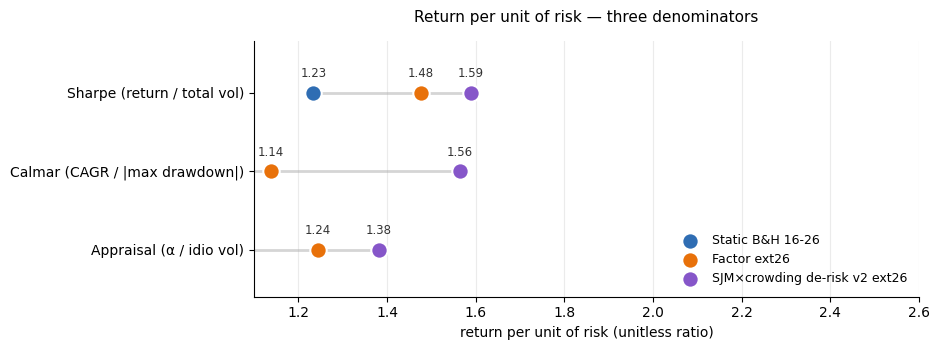

In [3]:
RATIOS = [("Sharpe (return / total vol)", "Sharpe"),
          ("Calmar (CAGR / |max drawdown|)", "Calmar"),
          ("Appraisal (α / idio vol)", "Appraisal")]

fig, ax = plt.subplots(figsize=(9.5, 3.6))
for i, (row_lbl, key) in enumerate(RATIOS):
    y = len(RATIOS) - 1 - i
    xs = [M[lbl][key] for _, lbl, _ in TRIO]
    ax.plot([min(xs), max(xs)], [y, y], color="#d5d5d5", lw=2, zorder=1)
    for _, lbl, _ in TRIO:
        d = M[lbl]
        ax.scatter(d[key], y, s=140, color=d["color"], edgecolor="white",
                   linewidth=1.5, zorder=3, label=lbl if i == 0 else None)
        ax.annotate(f"{d[key]:.2f}", (d[key], y), xytext=(0, 11),
                    textcoords="offset points", ha="center", fontsize=8.5, color=INK)
ax.set_yticks(range(len(RATIOS)), [r for r, _ in reversed(RATIOS)])
ax.set_xlabel("return per unit of risk (unitless ratio)")
ax.set_xlim(1.1, 2.6)
ax.grid(axis="x", alpha=0.25, zorder=0)
ax.legend(loc="lower right", frameon=False, fontsize=9)
ax.set_ylim(-0.6, 2.65)
ax.set_title("Return per unit of risk — three denominators", fontsize=11, pad=14)
fig.tight_layout()
fig.savefig(DATA / "nb18_ratio_ladder.png", dpi=300, bbox_inches="tight")
plt.show()

## 3. Metric profile — the seven headline metrics on one display

Parallel-coordinates profile: one vertical axis per metric, one line per
strategy, real values at each node. Every axis is oriented so that **up =
preferable** (max drawdown and idio vol run shallow/low at the top), and the
**vertical separation on each axis is proportional to that metric's relative
spread** across the trio — a near-tie is drawn nearly flat instead of being
stretched to the full band (plain min–max scaling would manufacture visual
separation from a 0.01 SSR spread). Read the *shape*: a line hugging the top
is dominant. Static B&H takes only the raw-CAGR axis; the v2 overlay tops or
ties every risk-adjusted axis; the flat SSR and σε axes say those differences
are small (see the 15_2 MBB verdicts for SSR).

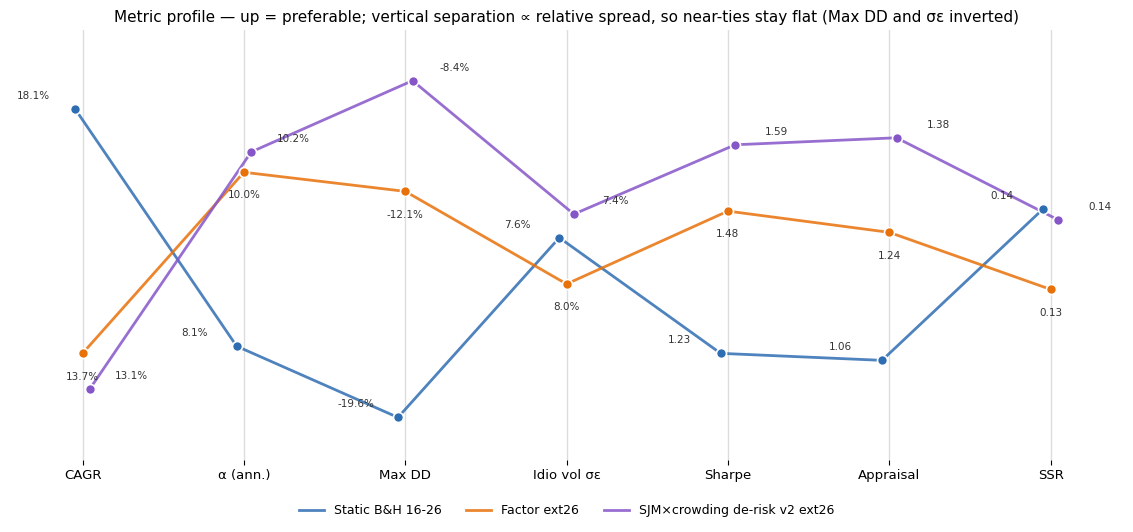

In [4]:
PROFILE = [("CAGR", "CAGR", "{:.1%}", False), ("α (ann.)", "alpha", "{:.1%}", False),
           ("Max DD", "maxDD", "{:.1%}", False),          # signed: shallow (larger) = top
           ("Idio vol σε", "idio", "{:.1%}", True),       # lower = top
           ("Sharpe", "Sharpe", "{:.2f}", False), ("Appraisal", "Appraisal", "{:.2f}", False),
           ("SSR", "SSR", "{:.2f}", False)]

fig, ax = plt.subplots(figsize=(11.5, 5.4))
positions = {}
for j, (name, key, fmt, invert) in enumerate(PROFILE):
    raw = np.array([M[lbl][key] for _, lbl, _ in TRIO])
    scaled = np.full(len(raw), 0.5) if np.ptp(raw) == 0 else (raw - raw.min()) / np.ptp(raw)
    if invert:
        scaled = 1 - scaled
    # band half-width proportional to the metric's RELATIVE spread (capped at 0.40):
    # a near-tie (SSR: 0.13-0.14) must LOOK like a near-tie — plain min-max would
    # stretch a 0.01 spread to the full band and manufacture separation from noise
    rel = np.ptp(raw) / max(1e-12, np.mean(np.abs(raw)))
    half = max(0.05, 0.40 * min(1.0, rel / 0.40))
    positions[j] = 0.5 + (scaled - 0.5) * 2 * half
    ax.axvline(j, color="#dddddd", lw=1, zorder=0)

DODGE = {0: -0.045, 1: 0.0, 2: 0.045}   # constant per-strategy x-offset: exact ties stay visible
for i, (_, lbl, color) in enumerate(TRIO):
    xs = [j + DODGE[i] for j in range(len(PROFILE))]
    ys = [positions[j][i] for j in range(len(PROFILE))]
    ax.plot(xs, ys, color=color, lw=2, zorder=2, alpha=0.85, label=lbl)
    ax.scatter(xs, ys, s=52, color=color, edgecolor="white", linewidth=1.2, zorder=3)
    lx, ly = [(-30, 6), (0, -13), (30, 6)][i]   # fixed per-strategy label slots: no collisions at ties
    for j, (name, key, fmt, invert) in enumerate(PROFILE):
        ax.annotate(fmt.format(M[lbl][key]), (xs[j], ys[j]), xytext=(lx, ly),
                    textcoords="offset points", ha="center",
                    va="bottom" if ly > 0 else "top", fontsize=7.5, color=INK)

ax.set_xticks(range(len(PROFILE)), [p[0] for p in PROFILE], fontsize=9.5)
ax.set_yticks([])
ax.set_ylim(0, 1.02)
ax.set_xlim(-0.45, len(PROFILE) - 0.55)
for side in ("left", "bottom"):
    ax.spines[side].set_visible(False)
ax.legend(loc="lower center", ncol=3, frameon=False, fontsize=9, bbox_to_anchor=(0.5, -0.16))
ax.set_title("Metric profile — up = preferable; vertical separation ∝ relative spread, "
             "so near-ties stay flat (Max DD and σε inverted)", fontsize=11)
fig.tight_layout()
fig.savefig(DATA / "nb18_metric_profile.png", dpi=300, bbox_inches="tight")
plt.show()

## Reading guide

- **Raw return:** static B&H wins CAGR — that is the cost of the de-risked seats,
  and the only axis it wins.
- **Per unit of risk:** the ordering flips on every denominator. The v2
  overlay earns the most per unit of total vol (raw-return Sharpe), per unit of
  drawdown (Calmar), and per unit of residual regression risk (Appraisal) — with
  the *lowest* risk on each axis, not by adding more.
- **Honesty row:** SSR is 0.13–0.14 across the board. Those are descriptive
  stability effect sizes, not standalone significance statistics. The risk-adjusted
  ranking above is a realized-sample statement, not a skill claim.

Figures are written to `data/nb18_*.png` at 300 dpi for direct thesis use.
Provenance: persisted equity artifacts + the nb17 price cache; conventions and
caveats (price-only SPY regression, elapsed-calendar CAGR, √252 volatility basis)
are those of `15_2`.